# Rotor Stability on Constant-Power Sections

Cuts the 2026-07-05 -> 07-09 laser step-down run down to the **settled** parts of the
long plateaus -- where the commanded laser power was held fixed and the spin frequency
had already relaxed to its steady state -- and plots the YAW spin frequency there.

This is deliberately narrow: it is about how *stable* the rotor is once it has settled,
not about the step response. The settling fits, PSD harmonic checks and noise-floor
budget live in `laser_stepdown_settling.ipynb`; this notebook only reuses that
notebook's plateau boundaries (via `laser_stepdown_steps.csv`) and its frequency
recipe (64 Hz -> bandpass -> Hilbert -> 30 s smoothing).

**Window definition.** For each plateau: drop the first `TRIM_START_TAU` damping times
(tau = 67.65 min) so the settling exponential is gone, and the last `TRIM_END_S`
seconds so the next commanded step is nowhere near the window. Keep what survives if
it is at least `MIN_FLAT_H` long. With the defaults below that selects the three long
holds -- steps 3, 7 and 11 -- the first of which is the 2026-07-07 00:00-16:00 stretch.

In [1]:
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime, timezone
from scipy.signal import decimate, butter, sosfiltfilt, hilbert
from scipy.ndimage import uniform_filter1d   # O(N) boxcar; np.convolve is O(N*M)

DATA_DIR = ('/Users/dcmoore/Yale University Dropbox/David Moore/shared_drives/'
            'Microspheres/TFINER/data')
ANALYSIS_DIR = ('/Users/dcmoore/Yale University Dropbox/David Moore/uspheres/TFINER/'
                'analysis/Decay-Sail/analysis')

YAW_FILES = [
    f'{DATA_DIR}/LES_yaw/Y1_RDS-LES_YAW_IN1_DQ_1467323190_1467582390.h5',
    f'{DATA_DIR}/LES_yaw/Y1_RDS-LES_YAW_IN1_DQ_1467582390_1467662710.h5',
]
PD_FILES = [
    f'{DATA_DIR}/PD/Y1_RDS-PD_IN1_DQ_1467323190_1467582390.h5',
    f'{DATA_DIR}/PD/Y1_RDS-PD_IN1_DQ_1467582390_1467662710.h5',
]
STEP_TABLE_CSV = f'{ANALYSIS_DIR}/laser_stepdown_steps.csv'

# GPS -> UTC: GPS epoch Jan 6 1980, 18 leap seconds
GPS_UNIX_OFFSET = 315964800 - 18

def gps_to_dt(gps):
    return datetime.fromtimestamp(gps + GPS_UNIX_OFFSET, tz=timezone.utc)

def dt_to_gps(dt):
    return dt.replace(tzinfo=timezone.utc).timestamp() - GPS_UNIX_OFFSET

TAU_FREE_MIN = 67.65          # free-decay damping time, spindown_20260702.ipynb
TAU_FREE_S   = TAU_FREE_MIN * 60.0

# -- frequency recipe (same as laser_stepdown_settling.ipynb) ----------------------
FS_RING       = 64.0          # Hz, after decimation
F_LOW, F_HIGH = 0.02, 8.0     # Hz bandpass; 8 Hz clears the fastest real rotation
SMOOTH_SEC    = 30.0          # instantaneous-frequency smoothing
PAD_S         = 600.0         # loaded either side of a window, discarded after filtering

## 1. Pick the flat windows

`laser_stepdown_steps.csv` already carries every detected plateau's start/end GPS time
and the commanded level. Trim and filter.

In [2]:
TRIM_START_TAU = 3.0    # damping times dropped from the start (settling transient)
TRIM_END_S     = 300.0  # s dropped from the end (guard against the next step)
MIN_FLAT_H     = 2.0    # h -- shorter survivors aren't worth calling "settled"

steps = pd.read_csv(STEP_TABLE_CSV)

windows = []
for _, r in steps.iterrows():
    t0 = r['t_start_gps'] + TRIM_START_TAU * TAU_FREE_S
    t1 = r['t_end_gps'] - TRIM_END_S
    dur_h = (t1 - t0) / 3600.0
    if dur_h < MIN_FLAT_H:
        continue
    # Plateaus 0-1 are the pre-sequence baseline: PD ~14 counts is below the laser's
    # ~735-count threshold, i.e. no drive at all, so there is no driven steady state
    # to be stable about. Excluded here; flip this test to look at the undriven rotor.
    if r['step'] <= 1:
        continue
    label = (f"step {int(r['step'])}: {int(r['counts'])} counts ({r['power_mw']:.2f} mW)"
             if np.isfinite(r['counts']) else
             f"step {int(r['step'])}: PD={r['pd_level']:.0f} (unmatched)")
    windows.append(dict(step=int(r['step']), label=label, t0=t0, t1=t1, dur_h=dur_h,
                        counts=r['counts'], power_mw=r['power_mw'],
                        f_ss=r['f_ss_fixed_gamma_hz']))

print(f"{len(windows)} flat windows "
      f"(trim {TRIM_START_TAU:.0f} tau = {TRIM_START_TAU*TAU_FREE_MIN/60:.1f} h off the front):\n")
for w in windows:
    print(f"  {w['label']:38s} {gps_to_dt(w['t0']):%Y-%m-%d %H:%M} -> "
          f"{gps_to_dt(w['t1']):%H:%M} UTC   ({w['dur_h']:5.2f} h)   "
          f"f_ss = {w['f_ss']:.4f} Hz")

print("\nPlateaus dropped as too short after trimming:")
for _, r in steps.iterrows():
    if r['step'] <= 1:
        continue
    dur_h = (r['t_end_gps'] - TRIM_START_TAU * TAU_FREE_S - TRIM_END_S - r['t_start_gps']) / 3600.0
    if dur_h < MIN_FLAT_H:
        print(f"  step {int(r['step']):2d}  held {r['duration_h']:5.2f} h "
              f"({r['duration_h']*60/TAU_FREE_MIN:4.2f} tau) -- nothing settled left over")

3 flat windows (trim 3 tau = 3.4 h off the front):

  step 3: 1600 counts (10.34 mW)         2026-07-07 00:14 -> 16:36 UTC   (16.37 h)   f_ss = 3.8819 Hz
  step 7: 1300 counts (6.66 mW)          2026-07-08 01:29 -> 16:01 UTC   (14.53 h)   f_ss = 2.7180 Hz
  step 11: 1000 counts (3.04 mW)         2026-07-09 01:29 -> 15:31 UTC   (14.03 h)   f_ss = 1.1341 Hz

Plateaus dropped as too short after trimming:
  step  2  held  0.67 h (0.59 tau) -- nothing settled left over
  step  4  held  2.50 h (2.22 tau) -- nothing settled left over
  step  5  held  1.17 h (1.03 tau) -- nothing settled left over
  step  6  held  1.42 h (1.26 tau) -- nothing settled left over
  step  8  held  2.17 h (1.92 tau) -- nothing settled left over
  step  9  held  2.92 h (2.59 tau) -- nothing settled left over
  step 10  held  0.75 h (0.67 tau) -- nothing settled left over
  step 12  held  1.17 h (1.03 tau) -- nothing settled left over
  step 13  held  1.08 h (0.96 tau) -- nothing settled left over
  step 14  held  1.

## 2. Load YAW and compute the spin frequency

Windowed reads only -- each window is decimated 1024 -> 64 Hz segment by segment, so
peak memory stays modest even for the 14-16 h stretches. `PAD_S` of extra data is read
on each side and thrown away after filtering, keeping the bandpass and Hilbert edge
transients out of the window.

**Cached.** Decimating + Hilbert-transforming three 14-16 h windows takes a few minutes,
so the resulting `(t, f, env)` arrays are cached to `.npz` under `CACHE_DIR` (outside
Dropbox, so nothing large syncs). The key covers the window bounds and every filter
parameter that changes the answer -- `FS_RING`, `F_LOW`, `F_HIGH`, `SMOOTH_SEC`, `PAD_S`
-- so changing any of them recomputes automatically. It does *not* checksum the source
HDF5 files: they are immutable archival exports, and skipping that check means a warm
cache reloads without touching (or needing to re-hydrate) them at all. Set
`USE_CACHE = False` to force a recompute, or `clear_cache()` to wipe it.


In [3]:
def load_window(files, gps_t0, gps_t1, fs_out=FS_RING):
    # Read [gps_t0, gps_t1] across the back-to-back exports, decimated to fs_out.
    t_list, y_list = [], []
    for path in files:
        with h5py.File(path, 'r') as f:
            fs   = float(f.attrs['sample_rate'])
            segs = f['segments/gps_start'][:].astype(np.float64)
            idxs = f['segments/index_start'][:].astype(np.int64)
            lens = f['segments/length'][:].astype(np.int64)
            dset = f['data']
            dec  = int(round(fs / fs_out))
            for gps0, ix, n in zip(segs, idxs, lens):
                seg_end = gps0 + n / fs
                if seg_end < gps_t0 or gps0 > gps_t1:
                    continue
                seg = dset[ix:ix + n].astype(np.float64)
                if dec == 16:
                    seg = decimate(decimate(seg, 4, zero_phase=True), 4, zero_phase=True)
                elif dec > 1:
                    seg = decimate(seg, dec, zero_phase=True)
                t_seg = gps0 + np.arange(len(seg)) / fs_out
                keep = (t_seg >= gps_t0) & (t_seg <= gps_t1)
                if keep.any():
                    t_list.append(t_seg[keep])
                    y_list.append(seg[keep])
    if not t_list:
        raise RuntimeError(f'no data in [{gps_t0}, {gps_t1}]')
    t = np.concatenate(t_list); y = np.concatenate(y_list)
    order = np.argsort(t)
    return t[order], y[order]


def inst_freq(y, fs=FS_RING, smooth_sec=SMOOTH_SEC):
    # Bandpass -> Hilbert -> smoothed instantaneous frequency and envelope.
    sos = butter(4, [F_LOW, F_HIGH], btype='bandpass', fs=fs, output='sos')
    yf  = sosfiltfilt(sos, y)
    analytic = hilbert(yf)
    phase    = np.unwrap(np.angle(analytic))
    f_inst   = np.diff(phase) / (2 * np.pi / fs)
    win      = max(1, int(smooth_sec * fs))
    return (uniform_filter1d(f_inst, size=win),
            uniform_filter1d(np.abs(analytic)[:-1], size=win))


# -- disk cache -------------------------------------------------------------------
import hashlib, time
from pathlib import Path

CACHE_DIR = Path.home() / '.cache' / 'decay_sail_rotor_stability'
CACHE_DIR.mkdir(parents=True, exist_ok=True)
USE_CACHE = True


# Bump when the smoothing/filtering implementation changes, not just its parameters.
# v2: boxcar switched from np.convolve('same') to uniform_filter1d -- same result to
# well within the noise, but the even-window centring convention differs by half a
# sample, so v1 caches are retired rather than silently mixed with v2 output.
CACHE_VERSION = 2


def _cache_key(t0, t1, files):
    # Everything that changes the result: the window and the whole filter recipe.
    # Source files are keyed by name only -- see the note above.
    sig = (CACHE_VERSION, round(float(t0), 3), round(float(t1), 3), FS_RING,
           F_LOW, F_HIGH, SMOOTH_SEC, PAD_S,
           tuple(sorted(Path(p).name for p in files)))
    return hashlib.md5(repr(sig).encode()).hexdigest()[:16]


def freq_for_window(t0, t1, files=YAW_FILES):
    """Cached (t, f, env) for a window. Returns (t, f, env, how) with how in
    {'cached', 'computed'}."""
    path = CACHE_DIR / f'yawfreq_{_cache_key(t0, t1, files)}.npz'
    if USE_CACHE and path.exists():
        with np.load(path) as z:
            return z['t'], z['f'], z['env'], 'cached'
    t_raw, y_raw = load_window(files, t0 - PAD_S, t1 + PAD_S)
    f_inst, env = inst_freq(y_raw)
    t_f = t_raw[:-1] + 0.5 / FS_RING
    keep = (t_f >= t0) & (t_f <= t1)                      # discard the pads
    t, f, e = t_f[keep], f_inst[keep], env[keep].astype(np.float32)
    if USE_CACHE:
        # note the .npz ending: np.savez appends '.npz' to anything that lacks it
        tmp = path.with_suffix('.tmp.npz')                # atomic: no half-written cache
        np.savez(tmp, t=t, f=f, env=e)
        tmp.replace(path)
    return t, f, e, 'computed'


def clear_cache():
    n = 0
    for p in CACHE_DIR.glob('yawfreq_*.npz'):
        p.unlink(); n += 1
    print(f'removed {n} cache files from {CACHE_DIR}')


# -- compute (or reload) every window ----------------------------------------------
for w in windows:
    t_start = time.time()
    w['t'], w['f'], w['env'], how = freq_for_window(w['t0'], w['t1'])
    print(f"{w['label']:38s} {len(w['f']):>9,} pts   "
          f"f = {np.median(w['f']):.4f} Hz   "
          f"(min {w['f'].min():.4f}, max {w['f'].max():.4f})   "
          f"[{how}, {time.time() - t_start:.1f} s]")

_mb = sum(p.stat().st_size for p in CACHE_DIR.glob('yawfreq_*.npz')) / 1e6
print(f"\ncache: {_mb:.0f} MB in {CACHE_DIR}")

step 3: 1600 counts (10.34 mW)         3,771,072 pts   f = 3.8650 Hz   (min 3.8624, max 3.8675)   [cached, 0.1 s]
step 7: 1300 counts (6.66 mW)          3,348,672 pts   f = 2.7203 Hz   (min 2.7057, max 2.7572)   [cached, 0.0 s]
step 11: 1000 counts (3.04 mW)         3,233,472 pts   f = 1.1281 Hz   (min 1.1153, max 1.1835)   [cached, 0.0 s]

cache: 207 MB in /Users/dcmoore/.cache/decay_sail_rotor_stability


## 3. Frequency on each flat window

Left: the full window at native 64 Hz resolution (decimated for drawing only).
Right: the same trace with its median removed, so the drift and wander are visible on
a fractional scale. The dashed line is the steady state the settling fit extrapolated
to in `laser_stepdown_settling.ipynb` -- an independent prediction, not a fit to these
points.

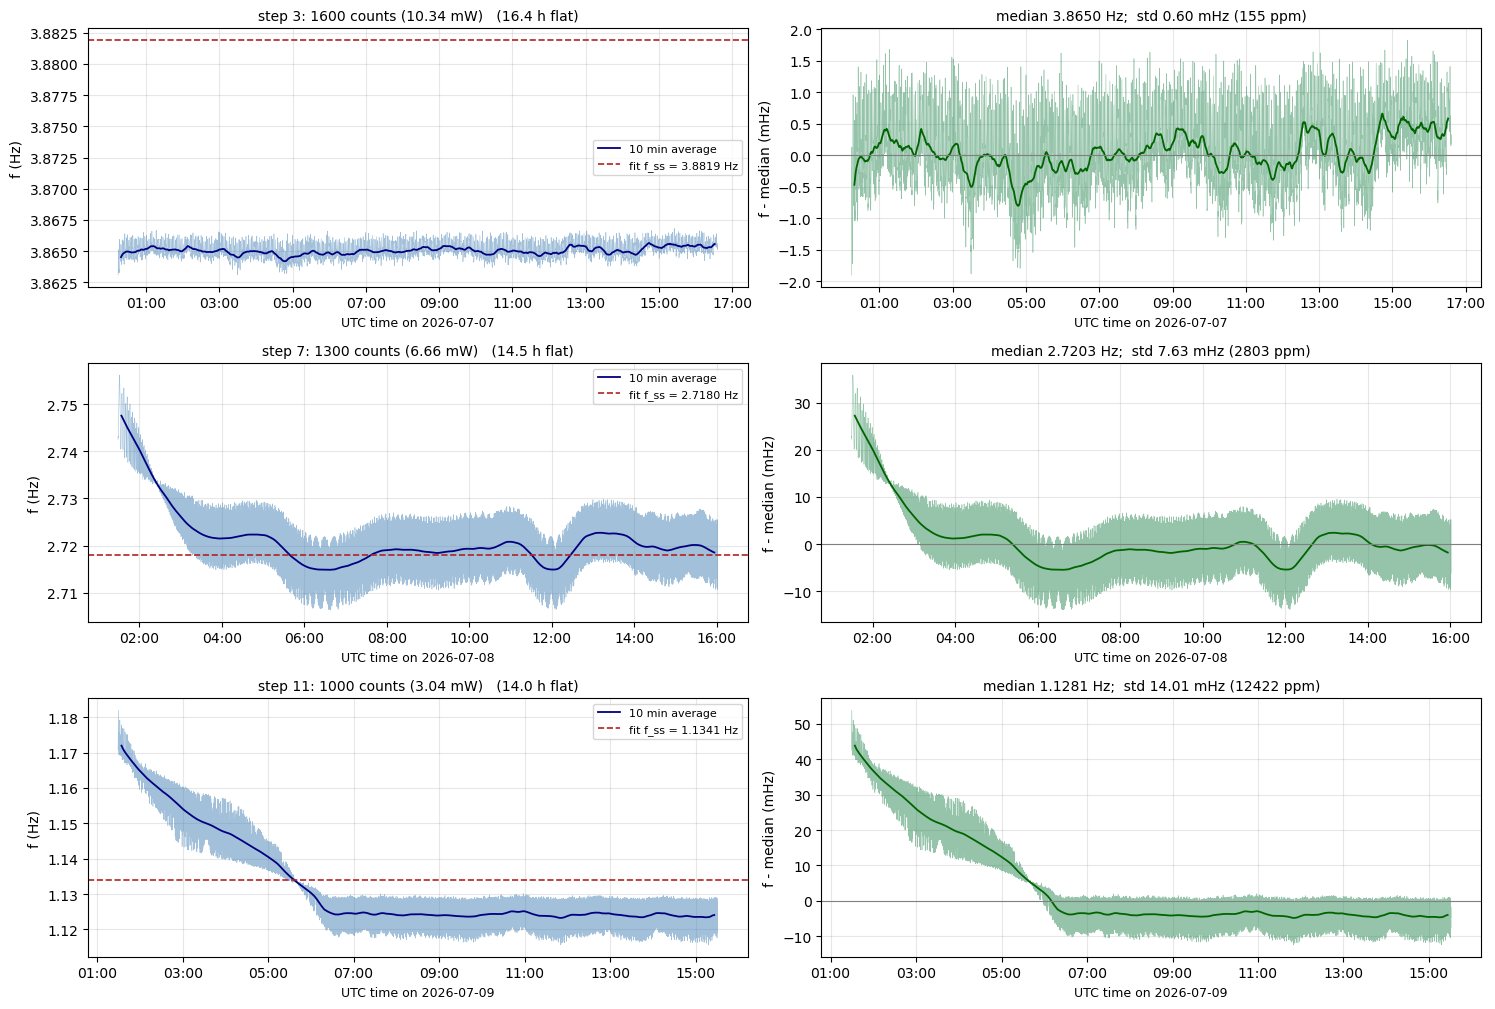

In [4]:
fig, axes = plt.subplots(len(windows), 2, figsize=(15, 3.4 * len(windows)),
                         squeeze=False)

SLOW_MIN = 10.0   # min -- boxcar for the overlaid slow trend

for (ax, axr), w in zip(axes, windows):
    stride = max(1, len(w['t']) // 6000)
    tt = [gps_to_dt(t) for t in w['t'][::stride]]
    ff = w['f'][::stride]
    fmed = np.median(w['f'])

    # slow trend: boxcar over SLOW_MIN, computed on the full-rate series
    nslow = int(SLOW_MIN * 60 * FS_RING)
    slow = uniform_filter1d(w['f'], size=nslow)[::stride]
    edge = max(1, nslow // (2 * stride))          # hide the boxcar's own edge roll-off
    tt_s, slow = tt[edge:-edge], slow[edge:-edge]

    ax.plot(tt, ff, lw=0.4, color='steelblue', alpha=0.5)
    ax.plot(tt_s, slow, lw=1.3, color='navy', label=f'{SLOW_MIN:.0f} min average')
    ax.axhline(w['f_ss'], color='firebrick', ls='--', lw=1.2,
               label=f"fit f_ss = {w['f_ss']:.4f} Hz")
    ax.set_ylabel('f (Hz)')
    ax.set_title(f"{w['label']}   ({w['dur_h']:.1f} h flat)", fontsize=10)
    ax.legend(fontsize=8, loc='best')
    ax.grid(True, alpha=0.3)

    axr.plot(tt, (ff - fmed) * 1e3, lw=0.4, color='seagreen', alpha=0.5)
    axr.plot(tt_s, (slow - fmed) * 1e3, lw=1.3, color='darkgreen')
    axr.axhline(0, color='gray', lw=0.8)
    axr.set_ylabel('f - median (mHz)')
    axr.set_title(f"median {fmed:.4f} Hz;  std {w['f'].std()*1e3:.2f} mHz "
                  f"({w['f'].std()/fmed*1e6:.0f} ppm)", fontsize=10)
    axr.grid(True, alpha=0.3)

    for a in (ax, axr):
        a.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
        a.xaxis.set_major_locator(mdates.HourLocator(interval=2))
        a.set_xlabel(f"UTC time on {gps_to_dt(w['t'][0]):%Y-%m-%d}", fontsize=9)

plt.tight_layout()
plt.show()

## 4. Stability summary

`std` is the raw scatter over the whole window; `drift` is a straight-line fit across
it (the slow wander that dominates that scatter); `std detrended` is what is left once
that line is removed. The gap between the last two is the honest statement of how much
of the instability is a slow trend rather than noise.

In [5]:
print(f"{'window':38s} {'hours':>6} {'median f':>10} {'std':>9} {'ppm':>7} "
      f"{'drift':>12} {'std detr':>9} {'ppm':>7}")
print('-' * 104)
for w in windows:
    ts = w['t'] - w['t'][0]
    fmed = np.median(w['f'])
    slope, icept = np.polyfit(ts, w['f'], 1)
    detr = w['f'] - (slope * ts + icept)
    w['slope_hz_per_h'] = slope * 3600
    w['std_raw'], w['std_detr'] = w['f'].std(), detr.std()
    print(f"{w['label']:38s} {w['dur_h']:6.2f} {fmed:9.4f}H {w['std_raw']*1e3:8.2f}m "
          f"{w['std_raw']/fmed*1e6:7.0f} {slope*3600*1e3:9.3f}mHz/h "
          f"{w['std_detr']*1e3:8.2f}m {w['std_detr']/fmed*1e6:7.0f}")

print("\n(H = Hz, m = mHz.  ppm is relative to that window's median frequency.)")

window                                  hours   median f       std     ppm        drift  std detr     ppm
--------------------------------------------------------------------------------------------------------
step 3: 1600 counts (10.34 mW)          16.37    3.8650H     0.60m     155     0.023mHz/h     0.59m     152


step 7: 1300 counts (6.66 mW)           14.53    2.7203H     7.63m    2803    -0.714mHz/h     7.01m    2578
step 11: 1000 counts (3.04 mW)          14.03    1.1281H    14.01m   12422    -2.698mHz/h     8.77m    7775

(H = Hz, m = mHz.  ppm is relative to that window's median frequency.)


## 5. Cross-check: was the laser actually flat?

The windows were defined from plateau boundaries, not re-verified. Overlay the PD
monitor on each one to confirm the drive really was constant across the window --
if a window's PD trace has structure in it, any frequency wander there is suspect.
Note the PD carries a +/-12-count etalon wiggle, so small excursions are the monitor,
not necessarily the laser.

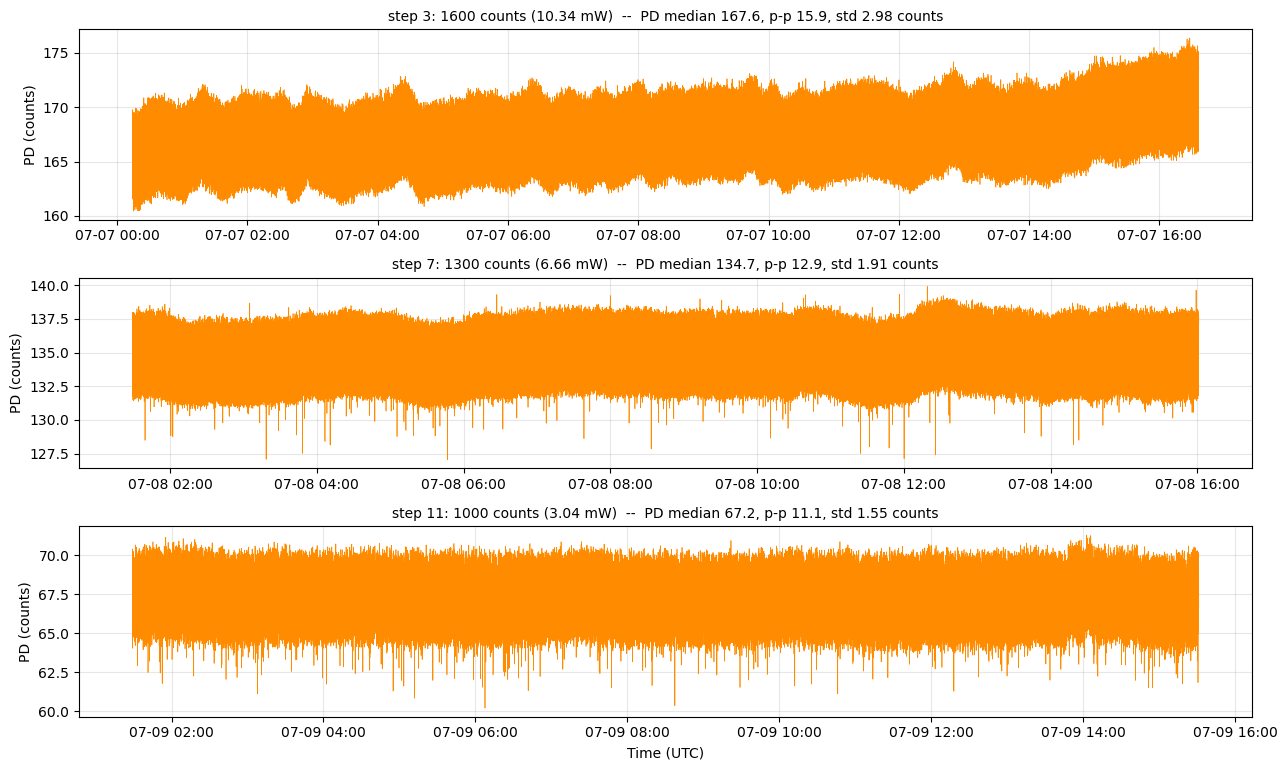

In [6]:
def load_window_strided(files, gps_t0, gps_t1, stride=1024):
    t_list, y_list = [], []
    for path in files:
        with h5py.File(path, 'r') as f:
            fs   = float(f.attrs['sample_rate'])
            segs = f['segments/gps_start'][:].astype(np.float64)
            idxs = f['segments/index_start'][:].astype(np.int64)
            lens = f['segments/length'][:].astype(np.int64)
            dset = f['data']
            for gps0, ix, n in zip(segs, idxs, lens):
                if gps0 + n / fs < gps_t0 or gps0 > gps_t1:
                    continue
                y_seg = dset[ix:ix + n:stride].astype(np.float32)
                t_seg = gps0 + np.arange(len(y_seg)) * stride / fs
                keep = (t_seg >= gps_t0) & (t_seg <= gps_t1)
                t_list.append(t_seg[keep]); y_list.append(y_seg[keep])
    t = np.concatenate(t_list); y = np.concatenate(y_list)
    order = np.argsort(t)
    return t[order], y[order]


fig, axes = plt.subplots(len(windows), 1, figsize=(13, 2.6 * len(windows)), squeeze=False)
for ax, w in zip(axes[:, 0], windows):
    t_pd, y_pd = load_window_strided(PD_FILES, w['t0'], w['t1'])
    ax.plot([gps_to_dt(t) for t in t_pd], y_pd, lw=0.5, color='darkorange')
    ax.set_ylabel('PD (counts)')
    ax.set_title(f"{w['label']}  --  PD median {np.median(y_pd):.1f}, "
                 f"p-p {np.ptp(y_pd):.1f}, std {y_pd.std():.2f} counts", fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M'))
axes[-1, 0].set_xlabel('Time (UTC)')
plt.tight_layout()
plt.show()

## 6. Step 3 in detail

Step 3 (1600 counts, 10.34 mW, 2026-07-07 00:14-16:36 UTC) is by far the most stable
of the three: 0.60 mHz over 16.4 h, ~40x quieter than steps 7 and 11, and with no
resolvable drift. Blown up here on a scale where 1 mHz is a large excursion.

- **Top:** the whole 16.4 h of `f - median` in microhertz, raw 30 s-smoothed trace
  behind, with 1 min / 10 min / 1 h boxcars over it. Each successive average is a
  factor sqrt(N) narrower if the noise is white -- if the 1 h curve is not visibly
  flat, the residual wander is correlated, not white.
- **Bottom left:** a 1 h slice, to see the structure the long view smears out.
- **Bottom right:** histogram of the raw trace, with a Gaussian of the same std.

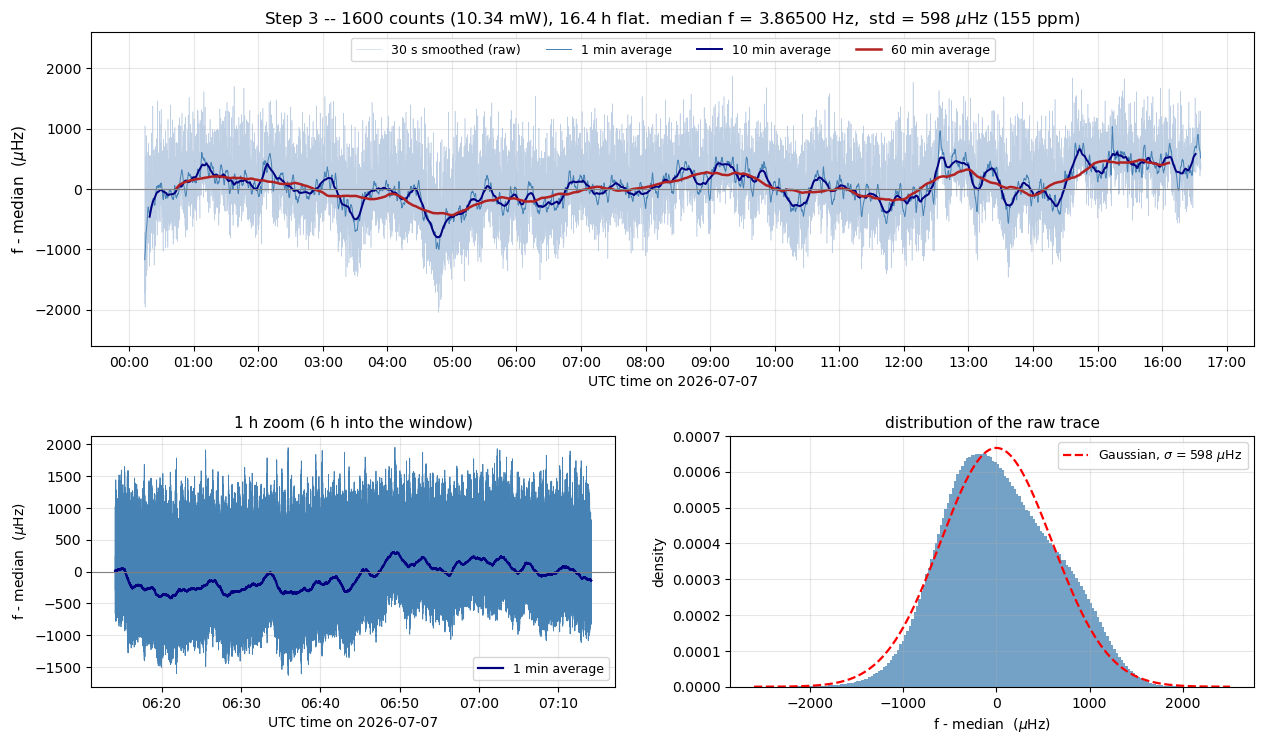

Averaging behaviour (step 3):
    boxcar |  std (uHz) |      ppm |  white-noise expectation
--------------------------------------------------------------
     0.5m |      301.1 |   77.912 |                    598.4
     1.0m |      298.5 |   77.225 |                    423.1
     2.0m |      293.2 |   75.860 |                    299.2
     5.0m |      280.2 |   72.487 |                    189.2
    10.0m |      266.3 |   68.903 |                    133.8
    30.0m |      226.8 |   58.686 |                     77.3
    60.0m |      205.5 |   53.158 |                     54.6
   120.0m |      184.7 |   47.780 |                     38.6

Drift across the window: 22.5 uHz/h (5.83 ppm/h)


In [7]:
w3 = next(w for w in windows if w['step'] == 3)
f0 = np.median(w3['f'])
resid_uhz = (w3['f'] - f0) * 1e6          # microhertz
t3 = w3['t']

def boxcar(x, minutes):
    n = int(minutes * 60 * FS_RING)
    sm = uniform_filter1d(x, size=n)
    e = n // 2
    return sm, e

fig = plt.figure(figsize=(15, 8.5))
gs  = fig.add_gridspec(2, 2, height_ratios=[1.25, 1], hspace=0.32, wspace=0.22)

# -- top: full window, blown up -----------------------------------------------------
ax = fig.add_subplot(gs[0, :])
stride = max(1, len(t3) // 8000)
ax.plot([gps_to_dt(t) for t in t3[::stride]], resid_uhz[::stride],
        lw=0.4, color='lightsteelblue', alpha=0.8, label='30 s smoothed (raw)')
for minutes, col, lwd in [(1, 'steelblue', 0.7), (10, 'navy', 1.4), (60, 'firebrick', 1.8)]:
    sm, e = boxcar(resid_uhz, minutes)
    ax.plot([gps_to_dt(t) for t in t3[e:-e:stride]], sm[e:-e:stride],
            lw=lwd, color=col, label=f'{minutes} min average')
ax.axhline(0, color='gray', lw=0.8)
ax.set_ylabel('f - median  ($\\mu$Hz)', fontsize=11)
ax.set_xlabel('UTC time on 2026-07-07')
ax.set_title(f"Step 3 -- 1600 counts (10.34 mW), {w3['dur_h']:.1f} h flat.  "
             f"median f = {f0:.5f} Hz,  std = {w3['f'].std()*1e6:.0f} $\\mu$Hz "
             f"({w3['f'].std()/f0*1e6:.0f} ppm)", fontsize=12)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax.xaxis.set_major_locator(mdates.HourLocator(interval=1))
ax.legend(fontsize=9, ncol=4, loc='upper center')
ax.grid(True, alpha=0.3)
ax.set_ylim(-2600, 2600)

# -- bottom left: 1 h zoom ----------------------------------------------------------
axz = fig.add_subplot(gs[1, 0])
zt0 = t3[0] + 6 * 3600.0                        # arbitrary quiet hour, 6 h in
zm  = (t3 >= zt0) & (t3 <= zt0 + 3600.0)
axz.plot([gps_to_dt(t) for t in t3[zm]], resid_uhz[zm], lw=0.6, color='steelblue')
sm1, e1 = boxcar(resid_uhz, 1)
axz.plot([gps_to_dt(t) for t in t3[zm]], sm1[zm], lw=1.6, color='navy',
         label='1 min average')
axz.axhline(0, color='gray', lw=0.8)
axz.set_ylabel('f - median  ($\\mu$Hz)')
axz.set_xlabel(f"UTC time on {gps_to_dt(zt0):%Y-%m-%d}")
axz.set_title('1 h zoom (6 h into the window)', fontsize=11)
axz.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
axz.legend(fontsize=9)
axz.grid(True, alpha=0.3)

# -- bottom right: distribution -----------------------------------------------------
axh = fig.add_subplot(gs[1, 1])
axh.hist(resid_uhz, bins=200, color='steelblue', alpha=0.75, density=True)
sd = resid_uhz.std()
xg = np.linspace(resid_uhz.min(), resid_uhz.max(), 400)
axh.plot(xg, np.exp(-0.5 * (xg / sd) ** 2) / (sd * np.sqrt(2 * np.pi)),
         'r--', lw=1.6, label=f'Gaussian, $\\sigma$ = {sd:.0f} $\\mu$Hz')
axh.set_xlabel('f - median  ($\\mu$Hz)')
axh.set_ylabel('density')
axh.set_title('distribution of the raw trace', fontsize=11)
axh.legend(fontsize=9)
axh.grid(True, alpha=0.3)

plt.show()

# -- how the scatter averages down --------------------------------------------------
print('Averaging behaviour (step 3):')
print(f"{'boxcar':>10} | {'std (uHz)':>10} | {'ppm':>8} | {'white-noise expectation':>24}")
print('-' * 62)
s_raw = resid_uhz.std()
for minutes in [0.5, 1, 2, 5, 10, 30, 60, 120]:
    n = int(minutes * 60 * FS_RING)
    nblk = len(resid_uhz) // n
    if nblk < 4:
        continue
    blocks = resid_uhz[:nblk * n].reshape(nblk, n).mean(axis=1)
    # white-noise expectation referenced to the 30 s smoothing already applied
    expect = s_raw * np.sqrt(30.0 / (minutes * 60))
    # blocks.std() is in uHz, f0 in Hz -> ppm = std_uHz*1e-6/f0*1e6 = std_uHz/f0
    print(f"{minutes:8.1f}m | {blocks.std():10.1f} | {blocks.std()/f0:8.3f} | "
          f"{expect:24.1f}")
print(f"\nDrift across the window: {w3['slope_hz_per_h']*1e6:.1f} uHz/h "
      f"({w3['slope_hz_per_h']/f0*1e6:.2f} ppm/h)")

## 7. Step 3 PSD vs the thermal floor

Welch ASD of the step-3 residual (linear trend removed, resampled to 1 Hz), against
the fluctuation-dissipation torque-noise floor computed with the *measured* damping
rate and the rotor moment of inertia:

$$S_\Omega(f) = \frac{4 k_B T \gamma}{I\,[\gamma^2 + (2\pi f)^2]}, \qquad S_f = S_\Omega/(2\pi)^2$$

Read it as: **lines** are periodic disturbances (findable and killable), the **slope of
the continuum** is the colour of the wander, and the **gap to the dashed curve** is how
far above thermally-limited this measurement sits at each Fourier frequency.

Caveats carried over from the frequency recipe: the instantaneous frequency is 30 s
smoothed, so everything above ~1/30 Hz is rolled off by construction (marked), and the
lowest bin or two can pick up leakage from residual slow trend.

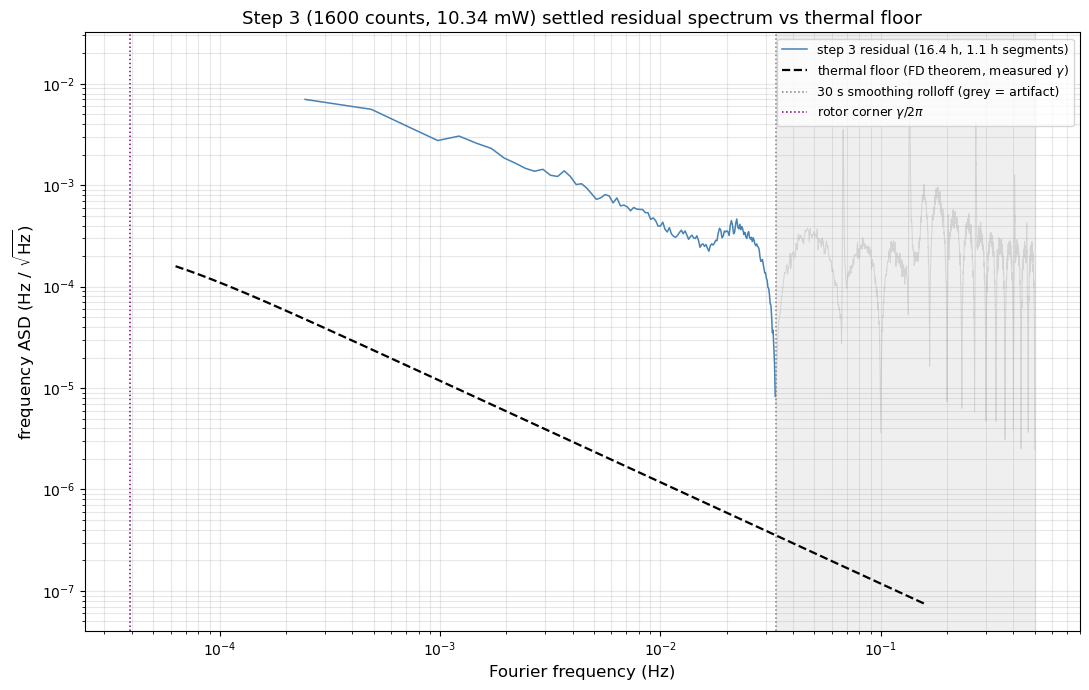

    f (Hz) |  ASD (Hz/rtHz) |      thermal |    ratio
------------------------------------------------------
   3.0e-04 |      6.715e-03 |    3.901e-05 |      172x
   1.0e-03 |      2.786e-03 |    1.179e-05 |      236x
   3.0e-03 |      1.384e-03 |    3.934e-06 |      352x
   1.0e-02 |      3.958e-04 |    1.180e-06 |      335x

Continuum slope over 3e-4 - 1e-2 Hz: ASD ~ f^-0.84 (f^-0.5 = 1/f power, f^-1 = 1/f^2 power / random walk)


In [8]:
from scipy.signal import welch

# -- constants (same sources as laser_stepdown_settling.ipynb) ---------------------
KB_J         = 1.380649e-23   # J/K
T_BATH       = 300.0          # K
I_TOTAL_KGM2 = 1.88e-11       # kg m^2 -- momentum-simulation/thermal_noise_spindown.py
GAMMA_FREE   = 1.0 / TAU_FREE_S
NPERSEG_S    = 4096           # s at 1 Hz -> resolves down to ~2.4e-4 Hz

def thermal_asd_f(f_hz):
    # FD-theorem torque-noise floor as a one-sided ASD of spin frequency (Hz/rtHz)
    s_om = 4 * KB_J * T_BATH * GAMMA_FREE / (
        I_TOTAL_KGM2 * (GAMMA_FREE**2 + (2 * np.pi * f_hz)**2))
    return np.sqrt(s_om) / (2 * np.pi)

# -- step-3 residual: linear trend removed, uniform 1 Hz resampling ----------------
w3 = next(w for w in windows if w['step'] == 3)
t3 = w3['t']
ts3 = t3 - t3[0]
slope3, icept3 = np.polyfit(ts3, w3['f'], 1)
resid3 = w3['f'] - (slope3 * ts3 + icept3)

tg = np.arange(t3[0], t3[-1], 1.0)
rg = np.interp(tg, t3, resid3)

freqs, psd = welch(rg, fs=1.0, nperseg=NPERSEG_S, scaling='density')
asd = np.sqrt(psd)

f_roll = 1 / SMOOTH_SEC          # everything above this is the 30 s boxcar, not the rotor
valid  = (freqs > 0) & (freqs < f_roll)

fig, ax = plt.subplots(figsize=(11, 7))
ax.loglog(freqs[valid], asd[valid], lw=1.1, color='steelblue',
          label=f"step 3 residual ({len(rg)/3600:.1f} h, {NPERSEG_S/3600:.1f} h segments)")
# past the rolloff the trace is the boxcar's sinc nulls and sidelobes -- show it, but
# greyed out and shaded, so it can't be mistaken for structure in the rotor
ax.loglog(freqs[freqs >= f_roll], asd[freqs >= f_roll], lw=0.7, color='lightgray', zorder=1)
ax.axvspan(f_roll, freqs[-1], color='gray', alpha=0.12, zorder=0)

f_line = np.logspace(-4.2, -0.8, 300)
ax.loglog(f_line, thermal_asd_f(f_line), 'k--', lw=1.6,
          label='thermal floor (FD theorem, measured $\\gamma$)')
ax.axvline(f_roll, color='gray', ls=':', lw=1.1,
           label=f'{SMOOTH_SEC:.0f} s smoothing rolloff (grey = artifact)')
ax.axvline(GAMMA_FREE / (2 * np.pi), color='purple', ls=':', lw=1.1,
           label='rotor corner $\\gamma/2\\pi$')
ax.set_xlabel('Fourier frequency (Hz)', fontsize=12)
ax.set_ylabel('frequency ASD (Hz / $\\sqrt{\\mathrm{Hz}}$)', fontsize=12)
ax.set_title('Step 3 (1600 counts, 10.34 mW) settled residual spectrum vs thermal floor',
             fontsize=13)
ax.legend(fontsize=9, loc='upper right')
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()

# -- where does it sit relative to thermal? ----------------------------------------
print(f"{'f (Hz)':>10} | {'ASD (Hz/rtHz)':>14} | {'thermal':>12} | {'ratio':>8}")
print('-' * 54)
for fq in [3e-4, 1e-3, 3e-3, 1e-2]:      # all below the smoothing rolloff
    a = np.sqrt(np.interp(fq, freqs, psd))
    th = thermal_asd_f(np.array([fq]))[0]
    print(f"{fq:10.1e} | {a:14.3e} | {th:12.3e} | {a/th:8.0f}x")

# slope of the continuum, fitted below the smoothing rolloff
band = (freqs > 3e-4) & (freqs < 1e-2)
p = np.polyfit(np.log10(freqs[band]), np.log10(asd[band]), 1)
print(f"\nContinuum slope over 3e-4 - 1e-2 Hz: ASD ~ f^{p[0]:.2f} "
      f"(f^-0.5 = 1/f power, f^-1 = 1/f^2 power / random walk)")